# Team 5 — IT5006 Phase 2: Analytics Implementation
## Problem definition, model building and evaluation — *Fair freight (regression) and late delivery (classification)*

Two problems, built on the Phase 1 candidate analysis, both about the logistics of an Olist order:

| | **Problem 1 — regression** | **Problem 2 — classification** |
|---|---|---|
| **Question** | What freight *should* this item be charged? | Will this order arrive after its promised date? |
| **Stakeholder** | Logistics-pricing / marketplace-finance analyst | Operations and customer-experience team |
| **Grain / target** | Order item · `log1p(freight_value)` | Delivered order · `is_late` = delivered on a calendar day after the promised date (Phase 1 definition, 6.8% positive) |
| **Validation** | 80/20 hold-out grouped by order; robustness by product and by time | **Time-ordered**: train on earlier orders, test on the latest 20%, 30-day embargo, forward-chaining CV |
| **Metrics** | MAE, RMSE, R² | Precision, Recall, F1, ROC-AUC, **PR-AUC and its lift over the late rate** |

**Model families (3), shared by both problems:** Linear (LinearRegression → Ridge; plain Logistic → L2 Logistic) · Tree-based (DecisionTree baseline → RandomForest) · Ensemble (Stacking for Problem 1; soft Voting for Problem 2, see Section 6).
Seed `RANDOM_STATE = 42` everywhere. All preprocessing sits inside scikit-learn `Pipeline`s.

**Reproduce:** put the nine Olist CSVs in `data/` (or set `OLIST_DATA_DIR`), `pip install -r requirements.txt`, run top to bottom (about 20 minutes on 12 cores; `PHASE2_FAST=1` runs a smoke test on a sample). `scripts/run_phase2.py` runs the same steps headless and writes the same tables and figures.

In [1]:
import os, sys, warnings, platform
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, sklearn
from IPython.display import display, Markdown
import features as F, models as M, pipeline as P, plots as PL

FAST = os.environ.get("PHASE2_FAST") == "1"      # smoke-test mode (small sample, tiny search)
np.random.seed(F.RANDOM_STATE)
FIG = os.path.abspath("../docs/phase2/figures"); TAB = os.path.abspath("../docs/phase2/tables")
os.makedirs(FIG, exist_ok=True); os.makedirs(TAB, exist_ok=True)
pd.set_option("display.float_format", "{:,.3f}".format); pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 120); pd.set_option("display.max_columns", 30)
def save(df, name): df.to_csv(os.path.join(TAB, name), index=False); return df
print(f"python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__} | seed {F.RANDOM_STATE} | FAST={FAST}")

python 3.14.3 | pandas 2.3.3 | numpy 2.4.2 | scikit-learn 1.8.0 | seed 42 | FAST=False


## 1. Problem statements and stakeholders

**Problem 1 — fair freight (regression).** Freight is about 14% of GMV and a median 23% of an item's price (Phase 1), yet roughly half of its variation is *not* explained by parcel weight, volume and distance. The **logistics-pricing / marketplace-finance analyst** who sets and audits freight needs an expected ("fair") freight for every item at checkout, to quote prices, review tariffs and spot items charged far above expectation.

**Problem 2 — late delivery (classification).** Delivery performance drives satisfaction: late orders average about 2.3 review stars against 4.3 for on-time ones (Phase 1). The **operations and customer-experience team** that sets delivery promises and intervenes on at-risk orders needs, at the moment of purchase, a **risk ranking** of orders likely to arrive after the promised date, so it can re-set the promise, expedite or contact the buyer.

**Success criteria (set before modelling).**
* Problem 1: a held-out MAE below 20% of mean freight (about R$4), beating the mean predictor and the linear baseline; errors reported by price band.
* Problem 2: on orders placed *after* the training period, a PR-AUC clearly above the late rate (lift > 1.5) and above the plain logistic baseline; when the riskiest 10% of orders are flagged, catch at least twice the late orders that random review would (recall ≥ 20%).
* For both: a more complex model is kept only if it beats its simpler baseline by more than one fold standard deviation of CV score.

### Problem-scoping checklist

In [2]:
items = F.build_item_table()
orders = F.build_order_table()
if FAST:
    ki = items.order_id.drop_duplicates().sample(15000, random_state=F.RANDOM_STATE)
    items = items[items.order_id.isin(ki)].reset_index(drop=True)
    orders = orders.iloc[::5].reset_index(drop=True)          # every 5th order keeps the time structure
display(save(P.scoping_checklist(orders), "scoping_checklist.csv"))

,Checklist item,Problem 1 (freight),Problem 2 (is_late)
0,"1. Target computable from provided tables, no external data",freight_value comes from order_items.,is_late = delivered date vs estimated date from orders (Phase 1 definition).
1,2. All predictors exist before the outcome (no leakage),"Listing, address and basket fields fixed at checkout.","Checkout-time fields, including the promised date, and history from orders delivered before the purchase; delivery, ..."
2,3. EDA shows feature-target relationships,Phase 1: freight correlates 0.61 / 0.59 / 0.39 with weight / volume / distance.,Phase 1: strong state gradient (SP 4.5% late vs AL 21.4%); late rate varies 1-19% by month.
3,4. Class imbalance has a mitigation plan,None needed (continuous target).,"6.8% late: PR-AUC and its lift as primary metrics, class_weight tuned, time-ordered validation, precision / recall /..."
4,5. A real business stakeholder,Logistics-pricing / finance analyst.,Operations and customer-experience team.


In [3]:
m = (orders.assign(month=orders.order_purchase_timestamp.dt.to_period("M").astype(str))
     .groupby("month").agg(orders=("clf_target", "size"), late_rate=("clf_target", "mean"),
                           promised_days=("promised_days", "median")).query("orders >= 300"))
display(Markdown("**Problem 2: late rate and median promised days by purchase month.** The late rate moves in episodes "
                 "(Nov 2017, Feb–Mar 2018) and Olist shortened its promises sharply in mid-2018, so a model must be "
                 "judged on orders placed after its training data."))
display(m.T.round(3))

**Problem 2: late rate and median promised days by purchase month.** The late rate moves in episodes (Nov 2017, Feb–Mar 2018) and Olist shortened its promises sharply in mid-2018, so a model must be judged on orders placed after its training data.

month,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08
orders,750.000,"1,653.000","2,546.000","2,303.000","3,545.000","3,135.000","3,872.000","4,193.000","4,150.000","4,478.000","7,288.000","5,513.000","7,069.000","6,556.000","7,003.000","6,798.000","6,749.000","6,096.000","6,156.000","6,351.000"
late_rate,0.029,0.030,0.046,0.066,0.030,0.030,0.028,0.029,0.044,0.042,0.124,0.075,0.057,0.141,0.190,0.045,0.066,0.012,0.034,0.062
promised_days,38.983,30.176,22.585,25.471,23.335,23.420,23.013,22.553,22.139,22.398,22.269,27.438,25.570,24.259,21.324,23.420,21.465,27.278,19.333,13.439


## 2. Data preparation and assumptions

* **Joins:** items ← orders (purchase time, promised and delivered dates, `customer_id`) ← customers (state, zip, `customer_unique_id`) ← sellers (state, zip) ← products (weight, size, category, listing text lengths) ← zip-prefix geolocation centroid (median lat/lon, Brazil bounding box only).
* **Problem 1 table (item grain):** 112,650 order-item lines. **Problem 2 table (order grain):** the 96,476 *delivered* orders that have both a delivered and an estimated date. Per order: sums of price, freight, weight, volume and chargeable weight, maximum seller-to-buyer distance, basket size, and the category, seller and seller state of the highest-priced item.
* **Derived:** Haversine distance; `chargeable_kg = max(weight, volume/5000)` (volumetric rule); `same_state`; purchase weekday/hour; `promised_days` = estimated date − purchase time (known at checkout).
* **Target of Problem 2:** `is_late = (delivered − estimated).dt.days > 0`, exactly as in Phase 1. The estimated date is a midnight timestamp, so this means "delivered on a calendar day after the promised date".
* **Customers:** `customer_unique_id` (the real person, not the per-order `customer_id`) is used to check customer overlap between train and test; no feature is customer-level.
* **Cleaning:** no row had price ≤ 0. Missing weight/dimensions, listing fields and distance (0.5% of rows, zip prefix absent from geolocation) are median-imputed **inside the pipeline with a missing-indicator**, so imputers learn from training folds only. Phase 1 proposed dropping rows without weight or volume; imputing keeps them and lets the indicator carry any signal. Unknown categories become `unknown`; rare categories/states (<20 rows) pool into an infrequent bucket.
* **Population:** Problem 2 can only be trained on delivered orders (the label does not exist otherwise), so orders that were cancelled or never delivered are out of scope (3.0% of orders). Problem 1 keeps all statuses, because freight is quoted at checkout.
* **Skew:** Problem 1 models `log1p(freight)` and reports back in R$; skewed numeric inputs are `log1p`-ed and standardised for the linear models only.

**Problem 1 table:** 112,650 items × 26 columns · 98,666 orders

**Problem 2 table:** 96,476 delivered orders × 27 columns · late rate 6.77% · 2016-09-15 to 2018-08-29

,chargeable_kg,desc_len,distance_km,name_len,photos_qty,volume_cm3,weight_kg
Problem 1: % missing,0.020,1.420,0.490,1.420,1.420,0.020,0.020
Problem 2: % missing,0.000,NaN,0.490,NaN,NaN,0.000,0.000


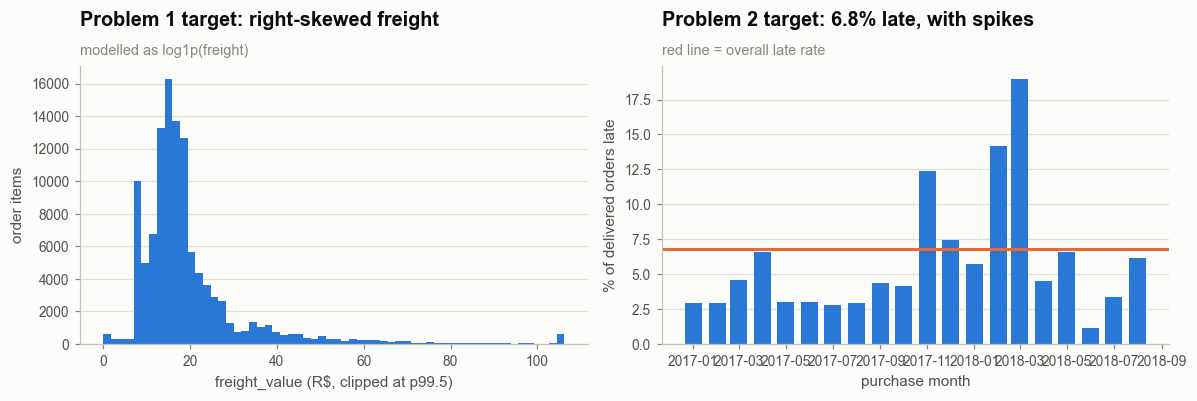

In [4]:
display(Markdown(f"**Problem 1 table:** {items.shape[0]:,} items × {items.shape[1]} columns · {items.order_id.nunique():,} orders"))
display(Markdown(f"**Problem 2 table:** {orders.shape[0]:,} delivered orders × {orders.shape[1]} columns · late rate {orders.clf_target.mean():.2%} · {orders.order_purchase_timestamp.min():%Y-%m-%d} to {orders.order_purchase_timestamp.max():%Y-%m-%d}"))
miss = pd.concat([(items.isna().mean() * 100).rename("Problem 1: % missing"), (orders.isna().mean() * 100).rename("Problem 2: % missing")], axis=1)
display(miss[(miss > 0).any(axis=1)].round(2).T)
PL.target_overview(items, orders, f"{FIG}/01_targets.png"); plt.show()

## 3. Feature engineering and leakage audit

Feature groups are nested so that Section 5 can test what each adds.

**Problem 1:** core drivers (weight, volume, chargeable weight, distance), geography and category, price and basket, listing and timing, and target-encoded seller identity.

**Problem 2:** everything is known when the order is placed. The core groups are:
* **delivery promise:** days between purchase and the estimated delivery date (Olist sets it at checkout);
* **route:** seller-to-customer distance, seller and customer states, and a same-state flag;
* **parcel and product:** total weight, volume, chargeable weight and product category;
* **order value and freight:** total price, total freight, freight-to-price ratio, and numbers of items and sellers.

Two further groups test whether *when* an order is placed helps: **purchase weekday and hour**, and **congestion** (the platform's order volume in the previous 7 days relative to its average week over the 28 days before that, plus the seller's 7-day order count; a ratio is used because raw volume grows with the business).

**Purchase month is excluded.** Only one November has delivered orders (2017), and February–March was late in 2018 (14–19%) but not in 2017 (3–5%), so month marks one-off episodes rather than a season that repeats; a check row in the ablation confirms it does not help forward in time.

In [5]:
display(Markdown("**Problem 1 feature sets**")); display(save(P.feature_set_table(F.FEATURE_SETS), "feature_sets_1.csv"))
display(Markdown("**Problem 2 feature sets**")); display(save(P.feature_set_table(F.LATE_FEATURE_SETS), "feature_sets_2.csv"))
display(Markdown("**Leakage audit**")); display(save(P.leakage_table(), "leakage_audit.csv"))

**Problem 1 feature sets**

,Feature set,Numeric,Categorical,Target-encoded
0,0 Price only (reference),price,-,-
1,"1 Core (weight, volume, distance)","weight_kg, volume_cm3, chargeable_kg, distance_km",-,-
2,2 + category & states,"weight_kg, volume_cm3, chargeable_kg, distance_km, same_state","seller_state, customer_state, category",-
3,3 + price & basket,"weight_kg, volume_cm3, chargeable_kg, distance_km, same_state, price, n_items, n_sellers","seller_state, customer_state, category",-
4,4 + listing & timing,"weight_kg, volume_cm3, chargeable_kg, distance_km, same_state, price, n_items, n_sellers, photos_qty, name_len, desc...","seller_state, customer_state, category",-
5,5 + seller (target-encoded),"weight_kg, volume_cm3, chargeable_kg, distance_km, same_state, price, n_items, n_sellers, photos_qty, name_len, desc...","seller_state, customer_state, category",seller_id


**Problem 2 feature sets**

,Feature set,Numeric,Categorical,Target-encoded
0,0 Promise only (reference),promised_days,-,-
1,"1 + route (distance, states)","promised_days, distance_km, same_state","seller_state, customer_state",-
2,2 + parcel & category,"promised_days, distance_km, same_state, weight_kg, volume_cm3, chargeable_kg","seller_state, customer_state, category",-
3,3 + order value & freight,"promised_days, distance_km, same_state, weight_kg, volume_cm3, chargeable_kg, price_total, freight_total, freight_ra...","seller_state, customer_state, category",-
4,4 + purchase weekday & hour,"promised_days, distance_km, same_state, weight_kg, volume_cm3, chargeable_kg, price_total, freight_total, freight_ra...","seller_state, customer_state, category",-
5,5 + congestion (7-day volume surge),"promised_days, distance_km, same_state, weight_kg, volume_cm3, chargeable_kg, price_total, freight_total, freight_ra...","seller_state, customer_state, category",-
6,Check: set 3 + purchase month,"promised_days, distance_km, same_state, weight_kg, volume_cm3, chargeable_kg, price_total, freight_total, freight_ra...","seller_state, customer_state, category",-


**Leakage audit**

,Problem,Field / group,Why it matters,Treatment
0,1,freight_value,Is the regression target,Never a predictor
1,1,"price, weight, dimensions, category, listing text lengths",Fixed on the listing at checkout,Allowed
2,1,"seller / customer state, zip-centroid distance",Seller listing and buyer address,Allowed
3,1,"n_items, n_sellers in the basket; purchase time parts",Known at order placement,Allowed
4,2,order_delivered_customer_date,Defines is_late; only known after delivery,"Target only, never a predictor"
5,2,"order_delivered_carrier_date, order_approved_at",Known only after payment clears / the seller ships,Never used
6,2,"review_* columns, order_status",Exist only after delivery; status is the final outcome,Never a feature; review score used only to measure business impact
7,2,order_estimated_delivery_date -> promised_days,The promise is set and shown at checkout,Allowed (as promised days)
8,2,"price, freight, weight, distance, category, states, basket, purchase time",Known at order placement,Allowed
9,2,"platform_surge_7d, seller_load_7d",Orders placed in the 7 days BEFORE this purchase (timestamps only),"Allowed (trailing window, no labels); tested, not kept"


## 4. Train/test discipline

**Problem 1.** 80/20 hold-out **grouped by `order_id`** (items of one order share basket fields) and stratified on target quintiles; 5-fold grouped CV on the training split.

**Problem 2 is validated forward in time.** The late rate moves in episodes and Olist's promises changed in 2018, so a random split lets the model see the same weeks in training and test and overstates what it can do on new orders (Section 8 measures by how much). We therefore:
* test on the **latest 20% of orders** by purchase time (from 26 May 2018);
* train on orders placed before that, leaving a **30-day embargo**: at the cut-off, orders from the last few weeks would not yet have been delivered, so their labels could not have been known (95% of orders are delivered within 30 days);
* tune and select with **5-fold forward-chaining CV**: the training orders are cut into six consecutive time blocks and each fold trains on the blocks before its validation block, with the same embargo;
* check the result on **four consecutive test windows** of about three months (Section 10): each is predicted by a model refitted on all orders before it, with the same embargo. The last window is the hold-out above.

Stratification cannot be combined with time ordering; instead every fold's late rate is reported and the metrics are made comparable across folds with **lift** (PR-AUC divided by the fold's late rate; 1 = no skill).

**How to read the evidence.** The forward-chaining CV (five periods from June 2017 to April 2018, late rates 3–13%) and the four windows are the main evidence of skill. The final hold-out is a **stress test**: within it Olist first lengthened its promises sharply (to a median of 37 days in the week of 28 May 2018) and then shortened them to about 13 days from the week of 30 July, and the late rate fell to 3.5%. Because `is_late` is defined against the promise, that window measures how the model copes with a policy change, not its typical skill.

In [6]:
strat_a = pd.qcut(items.reg_target.rank(method="first"), 5, labels=False)
tr_a, te_a = M.holdout_split(items, strat_a)
tr_b, te_b = M.time_holdout(orders)
assert not set(tr_a.order_id) & set(te_a.order_id) and not set(tr_b.order_id) & set(te_b.order_id), "orders leaked across a split"
assert tr_b.purchase_ts.max() < te_b.purchase_ts.min() - F.EMBARGO_DAYS * M.DAY, "embargo violated"
display(save(P.split_summary(tr_a, te_a, tr_b, te_b), "split_summary.csv"))
display(Markdown("**Problem 2 forward-chaining folds (training split only)**")); display(save(P.cv_fold_table(tr_b), "cv_folds_2.csv"))

,Split,Rows,Orders,Target,Purchase dates,Check
0,1 train,90120,78932,mean freight R$20.01,2016-09-04 to 2018-09-03,
1,1 test,22530,19734,mean freight R$19.93,2016-09-05 to 2018-08-29,77.8% of test items' products also in train
2,2 train,70241,70241,late rate 7.7%,2016-09-15 to 2018-04-26,30-day embargo before the test window
3,2 test,19295,19295,late rate 3.5%,2018-05-26 to 2018-08-29,2.0% of test orders from a customer also in train


**Problem 2 forward-chaining folds (training split only)**

,Fold,Train dates,Train orders,Train late rate,Validation dates,Validation orders,Validation late rate
0,1,2016-09-15 to 2017-05-07,8217,0.044,2017-06-06 to 2017-09-10,11707,0.030
1,2,2016-09-15 to 2017-08-11,19509,0.035,2017-09-10 to 2017-11-24,11707,0.059
2,3,2016-09-15 to 2017-10-25,29997,0.036,2017-11-24 to 2018-01-15,11707,0.091
3,4,2016-09-15 to 2017-12-16,41649,0.057,2018-01-15 to 2018-03-05,11707,0.132
4,5,2016-09-15 to 2018-02-03,51388,0.056,2018-03-05 to 2018-04-26,11706,0.108


## 5. Feature-set selection (training data only)

Does each added feature group earn its place? This also answers the Phase 1 question of whether seller, customer and timing variables add value beyond the core shipment drivers.
* **Problem 1:** a fast RandomForest, 3-fold grouped CV on a 40,000-row training sub-sample.
* **Problem 2:** forward-chaining CV with both base families (a fixed L2 logistic model and a fixed regularised forest). Because the folds differ a lot in difficulty, each group is judged by its **paired gain** in lift over the previous set, fold by fold; a group is kept only if that gain exceeds its fold standard deviation for at least one family.

**Problem 1: freight regression (CV MAE in R$)**

,Feature set,MAE (R$),RMSE (R$),R2 (R$)
0,0 Price only (reference),7.432,14.526,0.177
1,"1 Core (weight, volume, distance)",4.437,9.760,0.628
2,2 + category & states,4.017,9.161,0.673
3,3 + price & basket,3.858,8.920,0.690
4,4 + listing & timing,3.782,8.907,0.691
5,5 + seller (target-encoded),3.753,8.889,0.692


**Problem 2: is_late (forward-chaining CV; lift = PR-AUC / late rate; gain = paired change vs the previous set)**

,Feature set,Logit lift,Logit gain,Logit gain sd,Logit ROC-AUC,RF lift,RF gain,RF gain sd,RF ROC-AUC
0,0 Promise only (reference),0.969,NaN,NaN,0.501,0.996,NaN,NaN,0.504
1,"1 + route (distance, states)",1.970,1.001,0.433,0.677,1.807,0.811,0.353,0.656
2,2 + parcel & category,1.930,-0.040,0.065,0.673,1.804,-0.003,0.058,0.656
3,3 + order value & freight,1.992,0.062,0.055,0.682,1.827,0.023,0.034,0.654
4,4 + purchase weekday & hour,1.988,-0.004,0.026,0.680,1.839,0.013,0.043,0.653
5,5 + congestion (7-day volume surge),1.948,-0.040,0.084,0.677,1.615,-0.224,0.294,0.621
6,Check: set 3 + purchase month,1.902,-0.090,0.179,0.667,1.647,-0.179,0.197,0.630


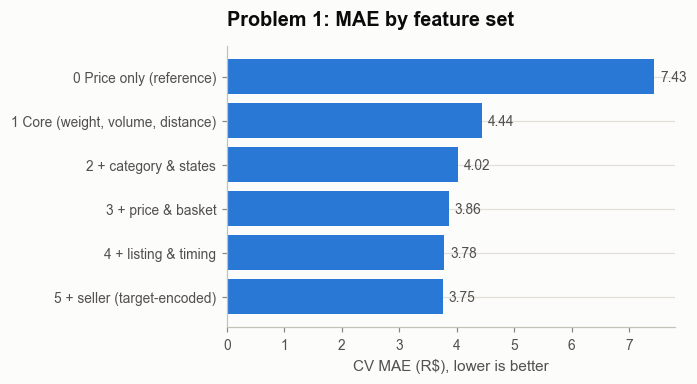

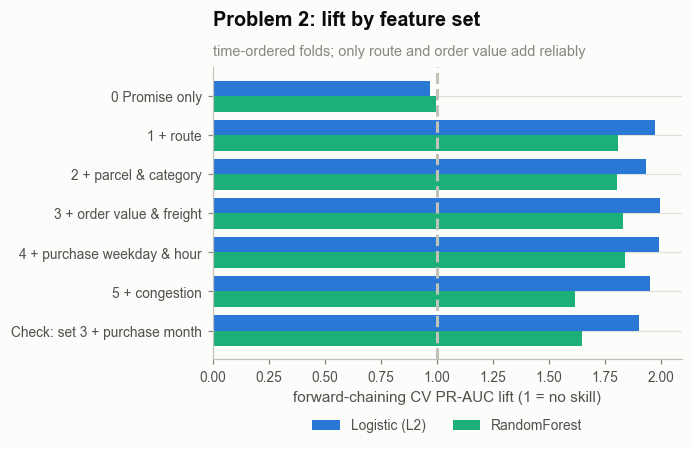

Modelling sets ->  Problem 1: 4 + listing & timing |  Problem 2: 3 + order value & freight


In [7]:
ab_a = save(P.ablation_regression(tr_a, n_rows=8000 if FAST else 40000), "ablation_1_regression.csv")
ab_b = save(P.ablation_classification(tr_b), "ablation_2_classification.csv")
display(Markdown("**Problem 1: freight regression (CV MAE in R$)**")); display(ab_a)
display(Markdown("**Problem 2: is_late (forward-chaining CV; lift = PR-AUC / late rate; gain = paired change vs the previous set)**")); display(ab_b)
PL.ablation_chart_reg(ab_a, f"{FIG}/02_ablation_1.png")
PL.ablation_chart_clf(ab_b, f"{FIG}/02_ablation_2.png"); plt.show()
fs_a = F.FEATURE_SETS[F.FULL_SET]; fs_b = F.LATE_FEATURE_SETS[F.LATE_FULL_SET]
cols_a, cols_b = P.cols_for(fs_a), P.cols_for(fs_b)
print("Modelling sets ->  Problem 1:", F.FULL_SET, "|  Problem 2:", F.LATE_FULL_SET)

**Problem 1 (freight).** Weight, volume and distance cut CV MAE from R$7.43 (price alone) to R$4.44. Category and states bring it to R$4.02, price and basket to R$3.86, and listing and timing to R$3.78. Target-encoded seller identity adds only R$0.03 (R$3.75), so it is not kept: the modelling set is **"4 + listing & timing"**.

**Problem 2 (is_late), forward in time.** The promise alone has no skill (lift 0.97 / 1.00). **Route information doubles the lift** (paired gain +1.00 ± 0.43 for the logistic model, +0.81 ± 0.35 for the forest). **Order value and freight** add +0.06 ± 0.06 for the logistic model, the only other group whose gain exceeds its fold sd. The timing groups do not transfer to later periods:
* purchase weekday and hour: about 0;
* the congestion ratio: −0.04 (logistic) and −0.22 (forest);
* **adding purchase month lowers lift** (−0.09 logistic, −0.18 forest), confirming that it encodes episodes, not seasons.

The modelling set is therefore **"3 + order value & freight"**: promised days, route, parcel and category, and order value and freight. The timing and congestion signals that dominated a random-split analysis (Section 8) do not survive the move to predicting later orders.

## 6. Models, baselines and hyper-parameter tuning

| Family | Baseline (simplest) | Tuned / advanced |
|---|---|---|
| Linear | `LinearRegression`, plain `LogisticRegression` (no penalty) | `Ridge(alpha)`, `LogisticRegression(C, class_weight)` |
| Tree-based | `DecisionTree` (lightly constrained: min leaf 5 / 20, otherwise default) | `RandomForest` (leaf size, max features, depth; class weight for Problem 2) |
| Ensemble | – | Problem 1: `Stacking` (Ridge + RandomForest → Ridge, inner 3-fold grouped CV). Problem 2: soft `Voting` (Logistic + RandomForest, tuned weight) |

A mean (Problem 1) or class-prior (Problem 2) dummy is the no-skill floor.

**Why voting rather than stacking for Problem 2.** A stacking meta-learner is trained on out-of-fold predictions for every training row, which a forward-in-time scheme cannot supply without predicting earlier orders from later ones. Soft voting needs no inner fit; its single weight is tuned on the same forward-chaining folds. Weighted voting is also the design Wani et al. (2022) used for delivery-delay prediction (Phase 1 literature review).

**Tuning.** Problem 1: full grid for Ridge `alpha`, randomised search (8 of 36 combinations) for the forest on a grouped sub-sample, 5-fold grouped CV, scored by MAE. Problem 2: full grid for Logistic `C` × `class_weight`, randomised search (20 of 240 combinations) for the forest on all training orders, grid for the voting weight; all on 5-fold forward-chaining CV, scored by **PR-AUC lift**.

**Handling imbalance in Problem 2 (class weights, no resampling).** `class_weight` (none / balanced / balanced-subsample) is a tuned hyper-parameter, and PR-AUC lift is the tuning score. We avoid SMOTE-style resampling because it distorts probability calibration (van den Goorbergh et al., 2022; Phase 1 literature review).

**From a risk score to a flag.** Precision, recall and F1 need a line between "flagged" and "not flagged". Because the late rate drifts from 1% to 19% by month, a fixed probability cut-off would flag almost nothing in some months and far too much in others. We therefore flag the **riskiest 10% of orders**, assuming the operations team can check about one order in ten; Section 10 shows what larger review shares would catch.

In [8]:
best_a, tune_a = P.tune_regression(tr_a, fs_a, n_iter=2 if FAST else 8, tune_rows=6000 if FAST else 30000)
best_b, tune_b = P.tune_classification(tr_b, fs_b, n_iter=3 if FAST else 20)
display(save(pd.concat([tune_a, tune_b], ignore_index=True), "tuning_log.csv")); print(best_a); print(best_b)

,Problem,Model,Search,Best params,CV score,Scored by
0,1 Regression,Ridge,grid (6),{'m__alpha': 10},0.198,MAE (log)
1,1 Regression,RandomForest,random (8 of 36),"{'m__n_estimators': 100, 'm__min_samples_leaf': 2, 'm__max_features': 0.33, 'm__max_depth': 16}",0.159,MAE (log)
2,2 is_late,Logistic (L2),grid (8),"{'m__C': 0.01, 'm__class_weight': 'balanced'}",1.993,PR-AUC lift
3,2 is_late,RandomForest,random (20 of 240),"{'m__n_estimators': 100, 'm__min_samples_leaf': 100, 'm__max_features': 0.3, 'm__max_depth': 10, 'm__class_weight': ...",1.857,PR-AUC lift
4,2 is_late,Voting (Logit + RF),grid (3),{'w_logit': 0.75},2.030,PR-AUC lift


{'ridge_alpha': 10, 'rf_reg': {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 0.33, 'max_depth': 16}}
{'logit_C': 0.01, 'logit_cw': 'balanced', 'rf_clf': {'n_estimators': 100, 'min_samples_leaf': 100, 'max_features': 0.3, 'max_depth': 10, 'class_weight': 'balanced'}, 'vote_w': 0.75}


## 7. Cross-validation (on each training split)

In [9]:
reg_models = P.final_reg_models(fs_a, best_a)
clf_models = P.final_clf_models(fs_b, best_b)
cv_a = save(P.cv_regression(reg_models, tr_a, fs_a), "cv_regression.csv")
display(Markdown("**Problem 1 — regression, 5-fold grouped CV (mean ± sd across folds)**")); display(cv_a)

**Problem 1 — regression, 5-fold grouped CV (mean ± sd across folds)**

,Model,MAE_rs mean,RMSE_rs mean,R2_rs mean,R2_log mean,MAE_rs sd,R2_rs sd
0,Mean predictor (dummy),7.811,16.049,-0.036,-0.000,0.087,0.002
1,Linear: LinearRegression,4.743,10.873,0.525,0.588,0.098,0.015
2,Linear: Ridge,4.743,10.877,0.525,0.588,0.098,0.015
3,Tree: DecisionTree (baseline),4.382,9.767,0.616,0.598,0.064,0.009
4,Tree: RandomForest,3.583,8.317,0.722,0.732,0.078,0.015
5,Ensemble: Stacking (Ridge + RF),3.589,8.202,0.730,0.732,0.073,0.015


In [10]:
cv_b, share_b = P.cv_classification(clf_models, tr_b, fs_b)
save(cv_b, "cv_classification.csv")
display(Markdown("**Problem 2 — is_late, 5-fold forward-chaining CV (mean ± sd). Precision / Recall / F1 for the riskiest 10% of orders in each validation block**")); display(cv_b)

**Problem 2 — is_late, 5-fold forward-chaining CV (mean ± sd). Precision / Recall / F1 for the riskiest 10% of orders in each validation block**

,Model,Review share,Precision mean,Recall mean,F1 mean,ROC_AUC mean,PR_AUC mean,Lift mean,F1 sd,PR_AUC sd,Lift sd
0,Prior predictor (dummy),0.100,0.082,0.095,0.084,0.500,0.084,1.000,0.031,0.040,0.000
1,Linear: LogisticRegression (plain),0.100,0.211,0.243,0.215,0.671,0.169,1.955,0.093,0.099,0.316
2,Linear: Logistic (L2),0.100,0.219,0.251,0.222,0.682,0.175,1.993,0.095,0.105,0.329
3,Tree: DecisionTree (baseline),0.100,0.145,0.172,0.148,0.557,0.113,1.317,0.056,0.063,0.175
4,Tree: RandomForest,0.100,0.204,0.235,0.208,0.656,0.162,1.851,0.093,0.095,0.309
5,Ensemble: Voting (Logit + RF),0.100,0.222,0.255,0.225,0.684,0.177,2.027,0.099,0.105,0.324


## 8. Held-out test evaluation and model selection

In [11]:
fit_a = P.fit_all(reg_models, tr_a, "reg_target", fs_a)
test_a = save(P.test_regression(fit_a, te_a, fs_a), "test_regression.csv")
display(Markdown("**Problem 1 — held-out test set** (R$ metrics on the original scale; `*_log` on the modelled log1p scale)")); display(test_a)

**Problem 1 — held-out test set** (R$ metrics on the original scale; `*_log` on the modelled log1p scale)

,Model,MAE_rs,RMSE_rs,R2_rs,MAE_log,RMSE_log,R2_log
0,Mean predictor (dummy),7.742,16.197,-0.033,0.356,0.526,-0.000
1,Linear: LinearRegression,4.738,11.068,0.518,0.199,0.343,0.574
2,Linear: Ridge,4.738,11.070,0.517,0.199,0.343,0.574
3,Tree: DecisionTree (baseline),4.376,9.947,0.610,0.182,0.328,0.610
4,Tree: RandomForest,3.552,8.452,0.719,0.150,0.273,0.731
5,Ensemble: Stacking (Ridge + RF),3.545,8.286,0.730,0.150,0.271,0.734


**Problem 2 — time-ordered test set** (orders from 26 May 2018; late rate 3.5%; riskiest 10% of orders flagged)

,Model,Review share,Flagged,Precision,Recall,F1,BalancedAcc,ROC_AUC,PR_AUC,Lift,Brier
0,Prior predictor (dummy),0.100,0.100,0.031,0.088,0.045,0.494,0.500,0.035,1.000,0.035
1,Linear: LogisticRegression (plain),0.100,0.100,0.079,0.227,0.118,0.566,0.670,0.072,2.061,0.042
2,Linear: Logistic (L2),0.100,0.100,0.072,0.205,0.106,0.554,0.657,0.066,1.900,0.265
3,Tree: DecisionTree (baseline),0.100,0.100,0.046,0.131,0.068,0.516,0.625,0.052,1.500,0.058
4,Tree: RandomForest,0.100,0.100,0.051,0.147,0.076,0.524,0.569,0.044,1.262,0.222
5,Ensemble: Voting (Logit + RF),0.100,0.100,0.066,0.188,0.098,0.546,0.640,0.063,1.790,0.252


**Problem 2 — the same models on a random split (grouped by customer_unique_id, late rate 6.8%) vs the time-ordered test.**

,Model,Random PR-AUC,Random lift,Random ROC-AUC,Time-ordered PR-AUC,Time-ordered lift,Time-ordered ROC-AUC
0,Prior predictor (dummy),0.068,1.000,0.500,0.035,1.000,0.500
1,Linear: LogisticRegression (plain),0.149,2.193,0.708,0.072,2.061,0.670
2,Linear: Logistic (L2),0.143,2.116,0.709,0.066,1.900,0.657
3,Tree: DecisionTree (baseline),0.110,1.631,0.612,0.052,1.500,0.625
4,Tree: RandomForest,0.153,2.260,0.714,0.044,1.262,0.569
5,Ensemble: Voting (Logit + RF),0.149,2.195,0.715,0.063,1.790,0.640


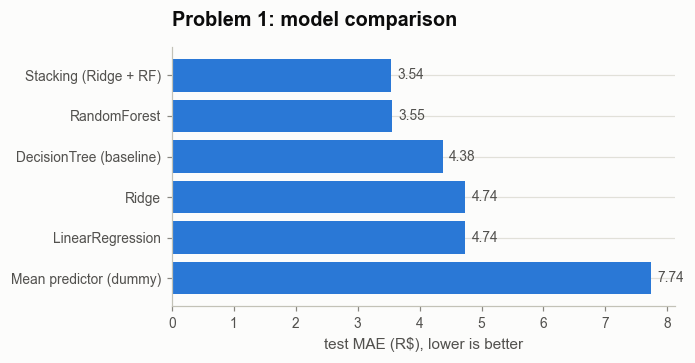

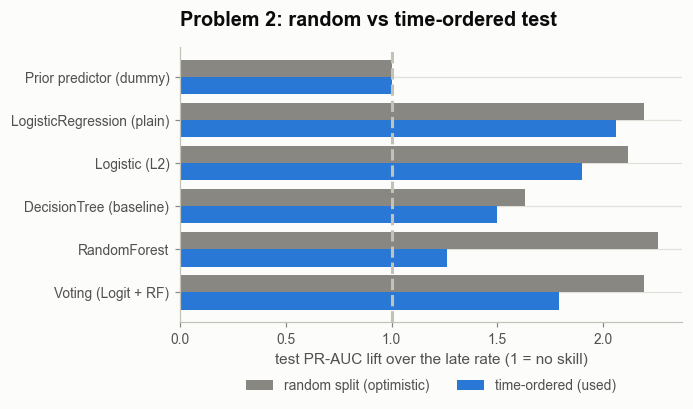

In [12]:
fit_b = P.fit_all(clf_models, tr_b, "clf_target", fs_b)
test_b = save(P.test_classification(fit_b, te_b, fs_b, share_b), "test_classification.csv")
display(Markdown(f"**Problem 2 — time-ordered test set** (orders from {te_b.order_purchase_timestamp.min():%d %b %Y}; late rate {te_b.clf_target.mean():.1%}; riskiest 10% of orders flagged)")); display(test_b)
cmp_b, rand_rate = P.split_comparison(clf_models, orders, fs_b, test_b)
save(cmp_b, "split_comparison_2.csv")
display(Markdown(f"**Problem 2 — the same models on a random split (grouped by customer_unique_id, late rate {rand_rate:.1%}) vs the time-ordered test.**"))
display(cmp_b)
PL.comparison_chart_reg(test_a, f"{FIG}/03_comparison_1.png")
PL.comparison_chart_clf(cmp_b, f"{FIG}/03_comparison_2.png"); plt.show()

In [13]:
# Final model per problem: simplest model within one fold sd of the best mean CV score
FINAL_A = P.pick_final(cv_a, "MAE_rs mean", "MAE_rs sd", False, P.ORDER_A)
FINAL_B = P.pick_final(cv_b, "Lift mean", "Lift sd", True, P.ORDER_B)
print("Final Problem 1:", FINAL_A, "| Final Problem 2:", FINAL_B)
def gap(tbl, a, b, col, sdcol):
    ra, rb = tbl.set_index("Model").loc[a], tbl.set_index("Model").loc[b]
    return f"{b} vs {a}: {col} {rb[col+' mean']:.3f} vs {ra[col+' mean']:.3f}  (diff={rb[col+' mean']-ra[col+' mean']:+.3f}; fold sd {ra[sdcol]:.3f} / {rb[sdcol]:.3f})"
for a, b in [("Linear: Ridge", "Tree: RandomForest"), ("Tree: DecisionTree (baseline)", "Tree: RandomForest"),
             ("Tree: RandomForest", "Ensemble: Stacking (Ridge + RF)")]:
    print("Problem 1 ", gap(cv_a, a, b, "MAE_rs", "MAE_rs sd"))
for a, b in [("Linear: LogisticRegression (plain)", "Linear: Logistic (L2)"), ("Linear: Logistic (L2)", "Tree: RandomForest"),
             ("Tree: DecisionTree (baseline)", "Tree: RandomForest"), ("Linear: Logistic (L2)", "Ensemble: Voting (Logit + RF)")]:
    print("Problem 2 ", gap(cv_b, a, b, "Lift", "Lift sd"))

Final Problem 1: Tree: RandomForest | Final Problem 2: Linear: LogisticRegression (plain)
Problem 1  Tree: RandomForest vs Linear: Ridge: MAE_rs 3.583 vs 4.743  (diff=-1.159; fold sd 0.098 / 0.078)
Problem 1  Tree: RandomForest vs Tree: DecisionTree (baseline): MAE_rs 3.583 vs 4.382  (diff=-0.798; fold sd 0.064 / 0.078)
Problem 1  Ensemble: Stacking (Ridge + RF) vs Tree: RandomForest: MAE_rs 3.589 vs 3.583  (diff=+0.005; fold sd 0.078 / 0.073)
Problem 2  Linear: Logistic (L2) vs Linear: LogisticRegression (plain): Lift 1.993 vs 1.955  (diff=+0.038; fold sd 0.316 / 0.329)
Problem 2  Tree: RandomForest vs Linear: Logistic (L2): Lift 1.851 vs 1.993  (diff=-0.142; fold sd 0.329 / 0.309)
Problem 2  Tree: RandomForest vs Tree: DecisionTree (baseline): Lift 1.851 vs 1.317  (diff=+0.534; fold sd 0.175 / 0.309)
Problem 2  Ensemble: Voting (Logit + RF) vs Linear: Logistic (L2): Lift 2.027 vs 1.993  (diff=+0.034; fold sd 0.329 / 0.324)


### 8.1 Model selection and ensemble justification
**Problem 1, regression: final model = RandomForest.**
Test MAE is R$3.55 against R$4.74 for Ridge, R$4.38 for the DecisionTree baseline and R$7.74 for the mean predictor; test R² is 0.719 against 0.517 and 0.610. In 5-fold CV the forest's MAE is 3.58 ± 0.08 against 4.74 ± 0.10 for Ridge, a gap of R$1.16, more than ten fold standard deviations. The complexity ladder is justified: the forest beats its single-tree baseline by R$0.80 and the linear family by R$1.16. Ridge is indistinguishable from plain LinearRegression (4.743 vs 4.743 CV MAE), so regularisation adds nothing. Stacking ties the forest (CV MAE 3.589 vs 3.583; test 3.545 vs 3.552) with a slightly lower RMSE (8.29 vs 8.45) that is within fold noise, so by the one-sd rule the single forest is kept and stacking is reported as a negative result.

**Problem 2, is_late: final model = plain LogisticRegression.**
In forward-chaining CV the soft vote has the highest mean lift (2.03 ± 0.32), followed by L2 logistic (1.99 ± 0.33), plain logistic (1.95 ± 0.32), RandomForest (1.85 ± 0.31) and the DecisionTree (1.32 ± 0.18). Every model from plain logistic upwards lies within one fold sd of the best, so the one-sd rule keeps the **simplest**, plain logistic regression. Within the tree family the forest does improve on its single-tree baseline (+0.53 lift, three fold sds), but it never overtakes the linear model.

The four test windows (Section 10) agree: logistic models lead the forest in every window, and plain logistic regression's lift is 1.47, 1.63, 2.14 and 2.06 (mean 1.82), always above chance and growing as more history is available. L2 logistic and the vote edge it by at most 0.16 in the first three windows, which is within the CV noise.

**Stress test (final hold-out, 26 May to 29 August 2018, late rate 3.5%).** Plain logistic regression keeps its skill through the promise changes: PR-AUC 0.072 (**lift 2.06**, ROC-AUC 0.670), ahead of L2 logistic (1.90), the vote (1.79), the DecisionTree (1.50) and the RandomForest (1.26). Flagging the riskiest 10% of orders gives precision 0.079, recall 0.227 and F1 0.118, against 0.031 / 0.088 / 0.045 for random review of the same 10%. Within the window its lift falls from 5.8 in June to 1.2 in August, after promises were cut to about 13 days (Section 10).

**Why the simplest model wins: random vs time-ordered evaluation.** Refitting the same specifications on a random split (grouped by customer) shows the cost of ignoring time. Plain logistic regression barely moves (lift 2.19 random vs 2.06 time-ordered), but the forest falls from 2.26 to 1.26. Flexible models learn which *weeks* were late (November 2017, February–March 2018), and a random split rewards them for recognising the same weeks in the test set.

**Ensemble: soft voting, tested and not selected.** The weighted vote (weight 0.75 on the logistic model, tuned forward in time) has the best CV lift but only +0.03 over L2 logistic against a fold sd of 0.32, and it falls behind on the test set (1.79). This follows Wani et al. (2022), who found that weighting the members of a voting classifier beats equal weights; here the forest member adds period-specific signal that does not transfer, so the vote is reported as a negative result.

**Success criteria.** Problem 1: test MAE R$3.55 is 17.8% of mean freight, under the 20% target, and beats both baselines; on never-seen listings it is R$4.04 (20.3%), at the limit (Section 11). Problem 2: lift 2.06 exceeds the 1.5 target, and no more complex model beat the plain logistic baseline, so the baseline itself is the final model. Flagging the riskiest 10% of orders catches 22.7% of late orders in the stress test, so the 20% recall target is met there, and 18–28% across the four windows, meeting it in 2 of 4 (W3 and W4; Section 10). Lift exceeds 1.5 in 3 of the 4 windows (W1: 1.47).

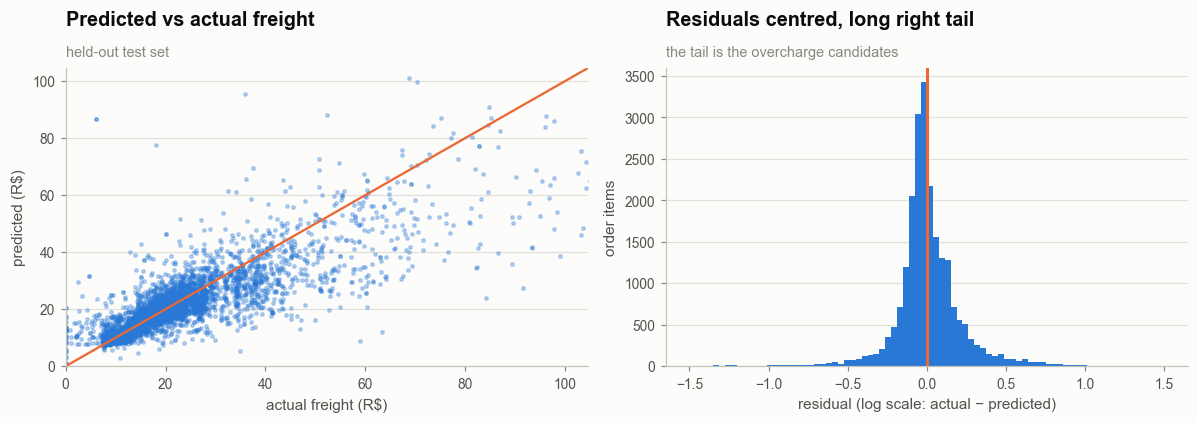

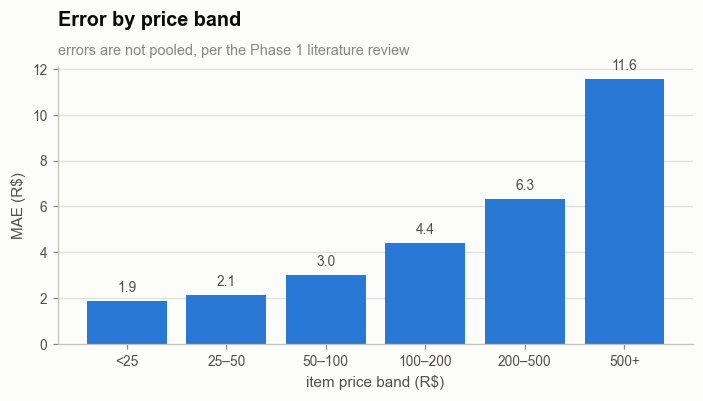

,band,MAE,MAE % of mean freight,n
0,<25,1.890,13.710,"2,784.000"
1,25–50,2.140,13.916,"5,131.000"
2,50–100,3.034,16.850,"6,604.000"
3,100–200,4.411,19.354,"5,337.000"
4,200–500,6.348,21.067,"2,053.000"
5,500+,11.550,24.441,621.000


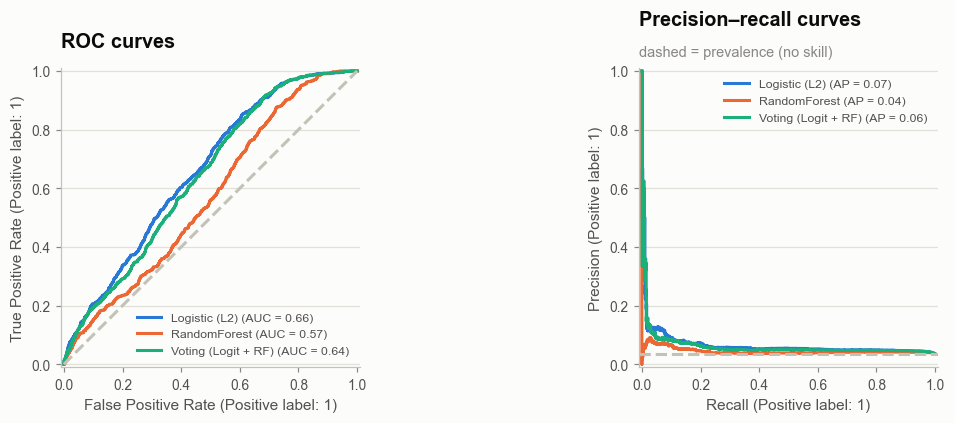

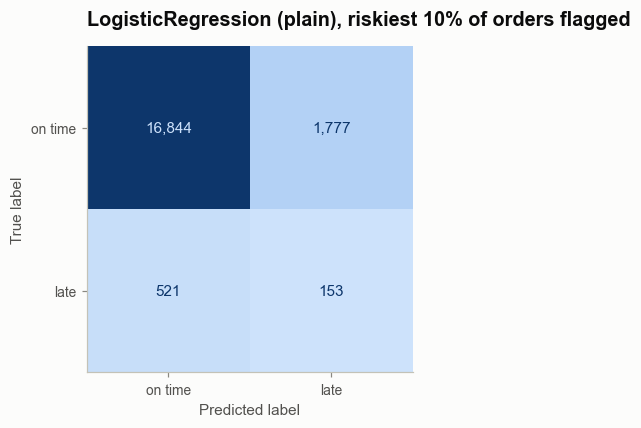

In [14]:
pred_a = fit_a[FINAL_A].predict(te_a[cols_a])
PL.pred_vs_actual(te_a.reg_target, pred_a, f"{FIG}/04_pred_vs_actual.png"); plt.show()
band = PL.error_by_price_band(te_a, pred_a, f"{FIG}/05_error_by_price_band.png"); plt.show()
display(save(band.reset_index(), "error_by_price_band.csv"))
PL.clf_curves(fit_b, te_b, cols_b, te_b.clf_target, f"{FIG}/06_roc_pr.png",
              ["Linear: Logistic (L2)", "Tree: RandomForest", "Ensemble: Voting (Logit + RF)"]); plt.show()
score_b = M.clf_scores(fit_b[FINAL_B], te_b[cols_b])
flags_b = M.flag_top_share(score_b, share_b[FINAL_B])
PL.confusion(te_b.clf_target, flags_b, f"{FIG}/07_confusion.png",
             f"{FINAL_B.split(': ')[-1]}, riskiest {share_b[FINAL_B]:.0%} of orders flagged"); plt.show()

## 9. Feature importance and interpretability

Permutation importance of the final models on the test sets (on the raw columns, so one-hot groups are not split) and standardised coefficients of the linear models. For Problem 2 we read the coefficients of the **L2** logistic model: with a full one-hot encoding the unpenalised model's state and category coefficients are not identifiable (only their differences are), while the penalty makes them stable; its CV lift is within 0.04 of the plain model.

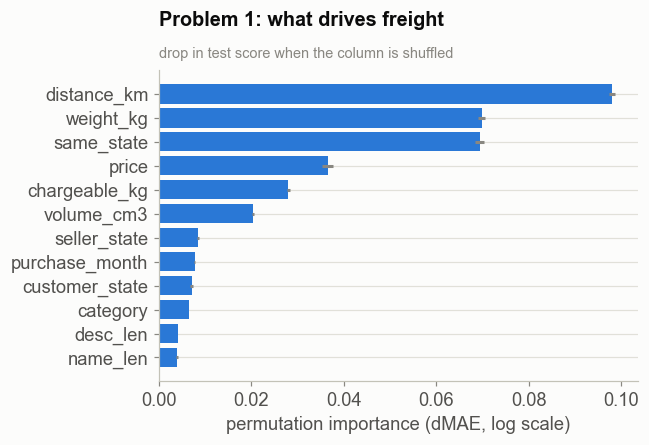

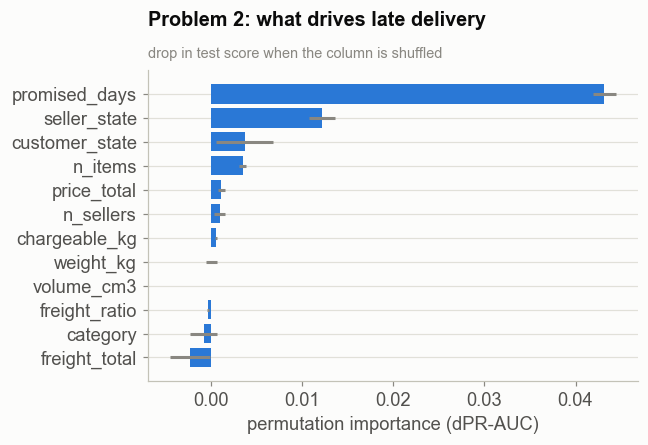

**Top standardised coefficients: Ridge (log freight)**

,feature,coef
0,category_furniture_mattress_and_upholstery,0.439
1,customer_state_RR,0.278
2,customer_state_RO,0.261
3,customer_state_SP,-0.255
4,category_kitchen_dining_laundry_garden_furniture,0.234
5,customer_state_PB,0.230
6,seller_state_MS,-0.224
7,customer_state_AC,0.223
8,customer_state_MA,0.223
9,customer_state_RS,-0.222


**Top standardised coefficients: Logistic L2 (log-odds of late)**

,feature,coef
0,promised_days,-0.665
1,customer_state_PR,-0.662
2,customer_state_MG,-0.649
3,customer_state_AL,0.618
4,customer_state_RJ,0.525
5,seller_state_SP,0.512
6,customer_state_DF,-0.477
7,customer_state_SP,-0.473
8,customer_state_PA,0.424
9,seller_state_RS,-0.423


In [15]:
imp_a = save(P.perm_importance(fit_a[FINAL_A], te_a, fs_a, "reg_target"), "perm_importance_1.csv")
imp_b = save(P.perm_importance(fit_b[FINAL_B], te_b, fs_b, "clf_target"), "perm_importance_2.csv")
PL.importance_bar(imp_a, "Problem 1: what drives freight", f"{FIG}/08_importance_1.png", unit="(dMAE, log scale)"); plt.show()
PL.importance_bar(imp_b, "Problem 2: what drives late delivery", f"{FIG}/09_importance_2.png", unit="(dPR-AUC)"); plt.show()
display(Markdown("**Top standardised coefficients: Ridge (log freight)**")); display(save(P.linear_coefs(fit_a["Linear: Ridge"]), "ridge_top_coefs.csv"))
display(Markdown("**Top standardised coefficients: Logistic L2 (log-odds of late)**")); display(save(P.linear_coefs(fit_b["Linear: Logistic (L2)"]), "logit_top_coefs.csv"))

## 10. Problem 2 over time: test windows, the stress test and customer satisfaction

The ops team cannot intervene on every order. Ranking orders by predicted risk shows how many late orders a limited review reaches. We check this four ways: on the final hold-out as a whole, month by month within it, across four consecutive test windows, and against the outcome the business ultimately cares about, the review score.

**Several test windows.** Each window (about three months) is predicted by the same specifications refitted on all orders before it, minus the 30-day embargo. The model specification (features and hyper-parameters) was chosen on data up to April 2018, so W1–W3 are consistency checks rather than untouched tests; only W4, the final hold-out, is fully untouched.

**Link to satisfaction.** Reviews are never a feature (they are written after the outcome), but they let us ask whether the orders the model flags go on to receive more 1–2 star reviews.

,decile,orders,late,late_rate,cum_capture,lift
0,1,1930,153,0.079,0.227,2.269
1,2,1929,78,0.040,0.343,1.158
2,3,1930,100,0.052,0.491,1.483
3,4,1929,85,0.044,0.617,1.261
4,5,1930,73,0.038,0.726,1.083
5,6,1929,73,0.038,0.834,1.083
6,7,1930,57,0.030,0.918,0.845
7,8,1929,37,0.019,0.973,0.549
8,9,1930,12,0.006,0.991,0.178
9,10,1929,6,0.003,1.000,0.089


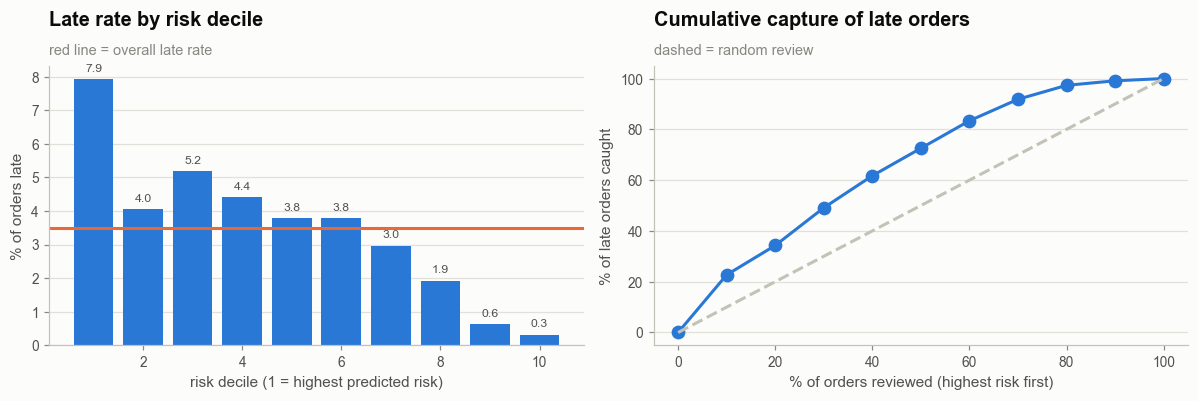

**Final model by month of the stress-test window**

,Month,Orders,Late rate,PR-AUC,Lift,ROC-AUC
0,2018-05,692.000,0.003,0.018,6.088,0.798
1,2018-06,"6,096.000",0.012,0.067,5.782,0.762
2,2018-07,"6,156.000",0.034,0.091,2.701,0.638
3,2018-08,"6,351.000",0.062,0.074,1.192,0.525


**Four consecutive test windows: lift by model (1 = no skill)**

Model,Prior predictor (dummy),LogisticRegression (plain),Logistic (L2),DecisionTree (baseline),RandomForest,Voting (Logit + RF)
Window,,,,,,
W1,1.000,1.465,1.509,1.116,1.424,1.533
W2,1.000,1.627,1.785,1.191,1.587,1.777
W3,1.000,2.142,2.171,1.400,2.100,2.205
W4,1.000,2.061,1.900,1.500,1.262,1.790


**Final model in each window, including the link to 1–2 star reviews**

,Test dates,Train orders,Test orders,Late rate,Median promise (days),PR-AUC,Lift,ROC-AUC,Recall@10%,Precision@10%,"Low-review rate, flagged","Low-review rate, not flagged",Share of low reviews flagged
Window,,,,,,,,,,,,,
W1,01 Sep 2017 to 30 Nov 2017,18237,15916,0.080,22.276,0.117,1.465,0.613,0.175,0.140,0.184,0.128,0.138
W2,01 Dec 2017 to 01 Mar 2018,30897,19139,0.091,25.562,0.148,1.627,0.640,0.192,0.175,0.198,0.154,0.125
W3,01 Mar 2018 to 26 May 2018,50268,19857,0.104,21.967,0.224,2.142,0.702,0.284,0.297,0.274,0.135,0.184
W4,26 May 2018 to 29 Aug 2018,70241,19295,0.035,20.342,0.072,2.061,0.670,0.227,0.079,0.110,0.095,0.114


**Lateness and 1–2 star reviews (descriptive)**

,metric,value
0,orders with a review,"95,830.000"
1,"low-review rate (1-2 stars), all",0.128
2,"low-review rate, late orders",0.624
3,"low-review rate, on-time orders",0.093
4,share of low reviews from late orders,0.324


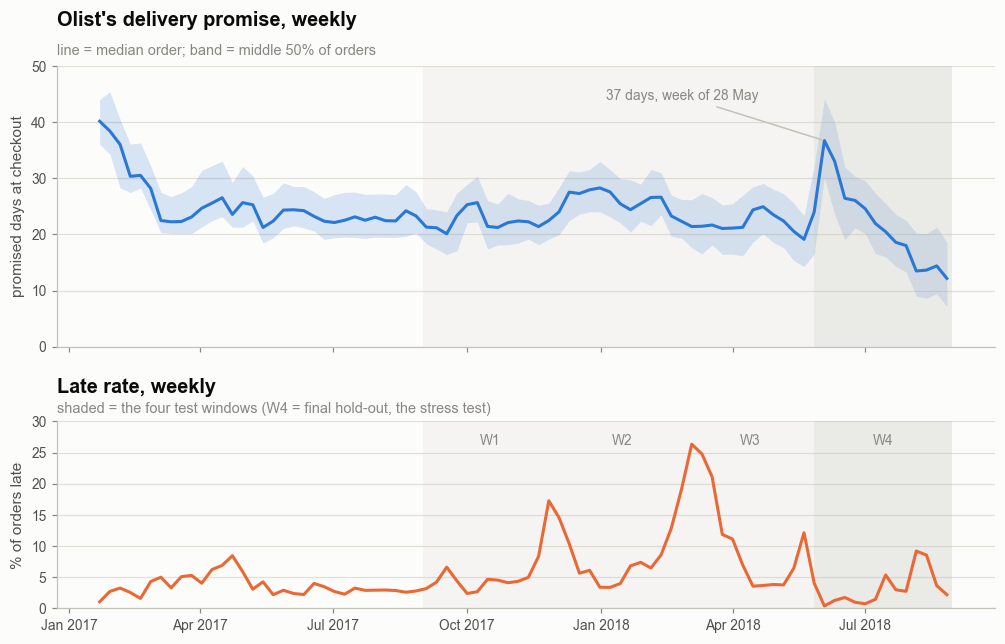

In [16]:
gain = save(P.gain_table(te_b.clf_target, score_b), "gain_table_2.csv")
display(gain); PL.gain_chart(gain, f"{FIG}/10_gain.png"); plt.show()
display(Markdown("**Final model by month of the stress-test window**")); display(save(P.test_by_month(fit_b[FINAL_B], te_b, fs_b), "test_by_month_2.csv"))
roll = save(P.rolling_windows(clf_models, orders, fs_b), "rolling_windows_2.csv")
display(Markdown("**Four consecutive test windows: lift by model (1 = no skill)**"))
display(roll.pivot(index="Window", columns="Model", values="Lift")[P.ORDER_B].rename(columns=lambda c: c.split(": ")[-1]))
display(Markdown("**Final model in each window, including the link to 1–2 star reviews**"))
display(roll[roll.Model == FINAL_B].drop(columns="Model").set_index("Window"))
display(Markdown("**Lateness and 1–2 star reviews (descriptive)**")); display(save(P.satisfaction_link(orders), "satisfaction_link_2.csv"))
wk = save(P.promise_timeline(orders), "promise_timeline_2.csv")
PL.promise_chart(wk, P.window_starts(orders), orders.order_purchase_timestamp.max(), f"{FIG}/12_promise_timeline.png"); plt.show()

**Results across windows.** Every model beats chance in every window, and skill grows as more history is available: plain logistic regression's lift is 1.47, 1.63, 2.14 and 2.06, the forest's 1.42, 1.59, 2.10 and 1.26. Logistic models lead in all four windows; L2 logistic and the vote edge plain logistic by at most 0.16 in W1–W3, and plain logistic is best in the stress test, where the forest falls back. W2 and W3 contain the late spikes (9.1% and 10.4% late) and the model keeps its ranking skill; W4 has the lowest late rate (3.5%) and the largest swings in the promise (top panel of the chart). Flagging the riskiest 10% of orders catches 18–28% of late orders.

**Satisfaction.** Late orders receive a 1–2 star review 62% of the time against 9% for on-time orders, but only 32% of all low reviews come from late orders. Accordingly, orders the model flags go on to receive low reviews 1.2–2.0 times as often as unflagged ones (for example 27.4% vs 13.5% in W3), and the flagged 10% of orders hold 11–18% of all low reviews, against 10% for random review: a real but modest payoff.

## 11. Problem 1: robustness, a transparent tariff and the unusual-freight audit

**Robustness.** 78% of test items are products that also appear in training, and a forest can partly memorise a listing's own past freight. We therefore re-test the tuned models on a hold-out **grouped by `product_id`** (every test item is a listing never seen in training) and on a **time-ordered** hold-out (latest 20% of items).

**Transparent tariff.** Phase 1 argued for keeping a model whose coefficients read as an implied tariff. A plain least-squares fit of freight on chargeable weight, distance and a same-state flag gives exactly that, in R$.

**Audit.** Phase 1 warned that a flexible model can absorb a seller's habitual overcharging into its fit. The audit therefore uses the **product-grouped** models: residuals are computed only on listings the models never saw. Items in the top 5% of positive log-residuals are flagged; with no ground-truth overcharge label we report *stability across two specifications* (RandomForest vs Ridge) and export the 30 items flagged most strongly by both, with their context, for manual review (precision-at-k, as proposed in Phase 1).

**Problem 1 — same tuned models on three hold-outs**

,Split,Model,MAE_rs,RMSE_rs,R2_rs
0,Order-grouped (main),Mean predictor (dummy),7.742,16.197,-0.033
1,Order-grouped (main),Linear: Ridge,4.738,11.070,0.517
2,Order-grouped (main),Tree: RandomForest,3.552,8.452,0.719
3,Product-grouped (unseen listings),Mean predictor (dummy),7.815,15.923,-0.033
4,Product-grouped (unseen listings),Linear: Ridge,4.875,11.010,0.506
5,Product-grouped (unseen listings),Tree: RandomForest,4.037,8.983,0.671
6,Time-ordered (latest 20%),Mean predictor (dummy),9.614,19.478,-0.072
7,Time-ordered (latest 20%),Linear: Ridge,6.124,14.245,0.427
8,Time-ordered (latest 20%),Tree: RandomForest,5.459,12.086,0.587


**Implied tariff (plain least squares, R$)**

,Term,Value
0,Base charge (R$),9.897
1,Per chargeable kg (R$),1.968
2,Per 100 km (R$),0.860
3,Same-state shipment (R$),-4.416
4,Test MAE of this tariff (R$),5.638


{'flag_rate': 0.05, 'jaccard': 0.531, 'overlap_share': 0.694}


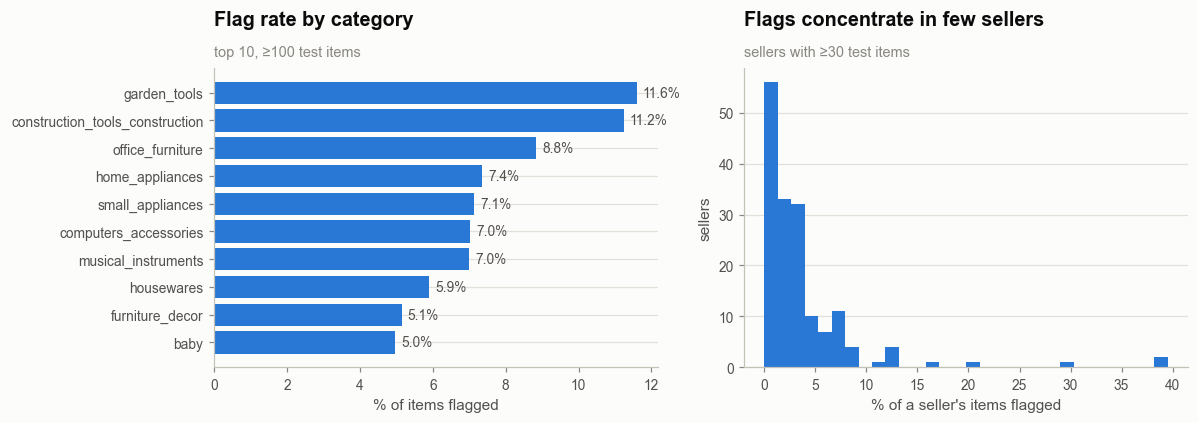

,metric,value
0,items flagged,"1,127.000"
1,mean actual freight R$,53.053
2,mean expected freight R$,26.517
3,mean excess R$,26.535
4,excess as % of all test freight,6.665
5,flagged items from top 5% of sellers (by flag count),57.232
6,flagged by both forest and Ridge (%),69.388


**Sellers with highest flag rates (≥30 test items)**

,seller_id,n,rate,excess
0,f80edd2c5aaa505cc4b0a3b219abf4b8,43,0.395,437.647
1,25c5c91f63607446a97b143d2d535d31,124,0.395,"1,260.732"
2,00ee68308b45bc5e2660cd833c3f81cc,67,0.299,377.996
3,ad781527c93d00d89a11eecd9dcad7c1,39,0.205,501.552
4,a1043bafd471dff536d0c462352beb48,276,0.163,"2,707.561"
5,1f50f920176fa81dab994f9023523100,373,0.131,"1,057.867"
6,d1c281d3ae149232351cd8c8cc885f0d,62,0.129,279.791
7,0dd184061fb0eaa7ca37932c68ab91c5,39,0.128,71.111
8,640e21a7d01df7614a3b4923e990d40c,58,0.121,157.526
9,17a053fcb14bd219540cbde0df490be0,34,0.118,223.001


**Manual review sheet: top 30 items flagged by both models**

,order_id,order_item_id,product_id,seller_id,category,price,freight_value,expected_rs,excess_rs,weight_kg,volume_cm3,chargeable_kg,distance_km,seller_state,customer_state,reviewer_verdict
0,9d817e85739426de1efcd842ee59cbd1,1,21d2fdced5c69bfc6539b67908a4ad28,1554a68530182680ad5c8b042c3ab563,furniture_living_room,177.990,207.780,31.887,175.893,6.450,"37,950.000",7.590,327.518,MG,RJ,
1,265b23c0727e5d7a2a3e36f5aac03d67,1,e26445edc4d665a7950a4b60461fc58d,527801b552d0077ffd170872eb49683b,books_general_interest,84.900,171.320,26.628,144.692,1.000,"9,856.000",1.971,"2,290.647",SP,CE,
2,fb9e94685fede37314f883d0bb0c2561,1,6391ff716e6d0271c58f47a692998cf7,902c99f1ac505c0d18778b61bcd636f7,housewares,24.490,64.800,10.364,54.436,0.550,"8,000.000",1.600,145.014,SP,SP,
3,5c0623ce8050c2cddeec3575bfbe0a53,2,4c8fae70c244a7ff63b9c1f73fb0a987,0b35c634521043bf4b47e21547b99ab5,construction_tools_construction,109.900,87.830,15.485,72.345,2.750,"4,232.000",2.750,"1,261.043",PR,ES,
4,faca7576168f770d89c21539ff07c9de,1,b91982b3afff5d274cf34ce54801a8e6,485452467ff670447e84a8370c3fc898,unknown,22.900,98.020,17.607,80.413,1.500,"48,000.000",9.600,351.003,SC,RS,
5,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,art,"6,499.000",227.660,42.767,184.893,7.400,"29,375.000",7.400,616.733,GO,SP,
6,cd51709c98c738351915f79c4318675e,7,3ebbc0870d51b62783c45e0e61ccb78d,7d456afc660226829370f3173d14520c,bed_bath_table,52.000,38.540,7.306,31.234,0.400,"2,592.000",0.518,5.345,SP,SP,
7,cd51709c98c738351915f79c4318675e,5,3ebbc0870d51b62783c45e0e61ccb78d,7d456afc660226829370f3173d14520c,bed_bath_table,52.000,38.540,7.306,31.234,0.400,"2,592.000",0.518,5.345,SP,SP,
8,cd51709c98c738351915f79c4318675e,4,3ebbc0870d51b62783c45e0e61ccb78d,7d456afc660226829370f3173d14520c,bed_bath_table,52.000,38.540,7.306,31.234,0.400,"2,592.000",0.518,5.345,SP,SP,
9,e520f0510b121c81ee4602e3851642af,1,53ea9da485f6aed8a6f03a85831fe021,7d13fca15225358621be4086e1eb0964,watches_gifts,277.990,68.820,13.808,55.012,0.346,"2,340.000",0.468,310.516,SP,SP,


In [17]:
names_a = ["Mean predictor (dummy)", "Linear: Ridge", "Tree: RandomForest"]
rob_a, (ptr, pte, pfit) = P.robustness_regression({n: reg_models[n] for n in names_a}, items, fs_a, test_a)
display(Markdown("**Problem 1 — same tuned models on three hold-outs**")); display(save(rob_a, "robustness_regression.csv"))
display(Markdown("**Implied tariff (plain least squares, R$)**")); display(save(P.implied_tariff(tr_a, te_a), "implied_tariff_1.csv"))
flagged, stab = P.flag_overcharge(pte, pfit["Tree: RandomForest"].predict(pte[cols_a]), pfit["Linear: Ridge"].predict(pte[cols_a]), q=0.95)
print({k: round(v, 3) for k, v in stab.items()})
sell = PL.overcharge_charts(flagged, f"{FIG}/11_freight_audit.png"); plt.show()
display(save(P.audit_summary(flagged), "freight_audit_summary.csv"))
display(Markdown("**Sellers with highest flag rates (≥30 test items)**")); display(save(sell.sort_values("rate", ascending=False).head(10).reset_index(), "freight_audit_top_sellers.csv"))
display(Markdown("**Manual review sheet: top 30 items flagged by both models**")); display(save(P.audit_review_sheet(flagged), "freight_audit_review_sheet.csv"))

## 12. Actionable insights
**Problem 2: operations and customer-experience team.**

1. **Use the model as a ranking, not a forecast.** Checking the riskiest 10% of orders reaches 22.7% of late orders in the stress test, more than twice what random checking would reach; the top 30% of orders by risk holds 49% of late orders and the top half 73%. Across the four test windows the same 10% catches 18–28% of late orders (W1–W4: 17.5%, 19.2%, 28.4%, 22.7%). Because precision is low (about 1 late order per 13 checked in the stress test), the intervention must be cheap: a proactive tracking message or a re-set promise, not expedited shipping for every flag.
2. **Late-risk flags carry a modest satisfaction payoff.** Late orders get a 1–2 star review 62% of the time against 9% for on-time orders. Flagged orders go on to receive low reviews 1.2–2.0 times as often as unflagged ones, and the flagged 10% hold 11–18% of all low reviews. Because about two-thirds (68%) of low reviews come from orders that arrived on time, preventing late deliveries addresses only part of dissatisfaction; the rest is product and seller quality.
3. **The promise is the lever, so treat estimator changes as events.** Promised days is by far the strongest signal (permutation importance 0.043 PR-AUC; L2 logistic coefficient −0.66 per standard deviation): longer promises make lateness much less likely. In August 2018 Olist cut the median promise from 21–27 days to 13 days; the late rate rose from 1.2% in June to 6.2% in August and the model's skill fell from lift 5.8 to 1.2. *Action:* when the promise rules change, re-train on the new regime and monitor late rate by promise length before trusting the ranking.
4. **Pad promises on high-risk lanes.** Holding the promise fixed, deliveries to Alagoas, Rio de Janeiro, Pará, Ceará and Maranhão, and from São Paulo sellers, carry higher late odds; deliveries to Paraná, Minas Gerais, the Federal District and within São Paulo carry lower ones.
5. **Do not plan around one Black Friday.** Calendar month, purchase timing and platform congestion added nothing, or hurt, when predicting later orders.

**Problem 1: logistics-pricing / finance analyst.**

6. **A fair-freight benchmark is feasible.** The forest predicts freight to within R$3.55 on average (R² 0.72), and R$4.04 for listings it has never seen, driven by distance, weight and whether seller and buyer share a state. *Action:* use it as a checkout sanity check. For a published tariff, the transparent least-squares version reads: **R$9.90 base + R$1.97 per chargeable kg + R$0.86 per 100 km − R$4.42 within a state** (MAE R$5.64, the price of full transparency).
7. **Unusual freight is concentrated, so audit sellers.** On never-seen listings, 1,127 items (the top 5% of residuals) were charged R$53.1 against R$26.5 expected, a mean excess of R$26.5 and 6.7% of all freight in that test set; the top 5% of sellers account for 57% of the flags, and the forest and Ridge agree on 69% of them. *Action:* review items flagged by both models first; the 30 strongest are in `freight_audit_review_sheet.csv` for manual checking.
8. **Be cautious on expensive items.** Test MAE rises from R$1.9 for items under R$25 to R$11.6 above R$500 (13.7% to 24.4% of mean freight), so use wider tolerance bands before flagging high-ticket items.

## 13. Limitations and constraints
* **Problem 2 skill is modest and decays.** Lift is about 2 on later orders, and within the three-month test window it falls to 1.2 by August 2018 after the change in promise rules. The model needs monthly re-training with forward validation and monitoring of lift by month. Carrier performance, weather and strikes are not in the data, so a ceiling on predictability is expected.
* **Test windows.** There are four, but W1–W3 lie inside the period used to choose the model specification, so only W4 is untouched, and W4 is unusual (late rate 3.5% against 7.7% in training, and two promise changes). No confidence intervals are reported on test metrics.
* **Probabilities are not calibrated.** Because the late rate shifts between periods, predicted probabilities are too high on the test window (Brier 0.042 against 0.035 for a constant at the test late rate). The scores are used only as rankings; recalibrating on the latest month would be needed before quoting probabilities.
* **Label and population.** `is_late` means delivered on a calendar day after the promised date and exists only for delivered orders, so the 3% never delivered are out of scope. Order-level aggregation (maximum distance, highest-priced item's seller and category) discards multi-seller detail.
* **Problem 1 inputs.** Distance is straight-line between zip-prefix centroids, not route distance; how Olist allocates an order's freight across items is undocumented; seller-funded shipping, promotions and carrier tariffs are not in the data. Back-transforming log predictions gives median-like expected freight, so mean excess is slightly overstated. There is no ground-truth overcharge label: flags are leads for review, and the manual review of the top 30 is still to be done.
* **Search and evaluation budget.** The Problem 1 forest was tuned with 8 random draws on a 30,000-row sub-sample; the Problem 2 forest with 20 draws. Permutation importance splits credit between correlated features.

## 14. Reproducibility and AI use
Seed `42` for splits, CV, forests, subsampling and target-encoder cross-fitting. Environment: `requirements.txt` (results produced with the versions printed in the first code cell). Headless run: `python scripts/run_phase2.py` writes the same tables to `docs/phase2/tables/` and figures to `docs/phase2/figures/`.

*AI use:* Anthropic Claude (via Claude Code) was used to help write and refactor the analysis code, run experiments and draft text. The team reviewed and takes responsibility for all code, results and interpretation.